# Блок 1: Импорт необходимых библиотек

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


# Блок 2: Загрузка датасетов

In [22]:
try:
    # Загрузка датасета Gun Violence
    gun_data = pd.read_csv('gun-violence-data.csv')
    
    # Загрузка датасета Anime
    anime_data = pd.read_csv('anime.csv')
    
    print("Датасеты успешно загружены")
    print(f"Gun Violence Data: {gun_data.shape}")
    print(f"Anime Data: {anime_data.shape}")
    
except FileNotFoundError as e:
    print(f"Ошибка загрузки файлов: {e}")
    print("Убедитесь, что файлы находятся в той же директории")

Датасеты успешно загружены
Gun Violence Data: (239677, 29)
Anime Data: (12294, 7)


# Блок 3: Предобработка данных для регрессии (Gun Violence)

Размер датасета для регрессии: (10000, 6)
Распределение целевой переменной:
count    10000.000000
mean         0.695900
std          0.832642
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         25.000000
Name: total_victims, dtype: float64


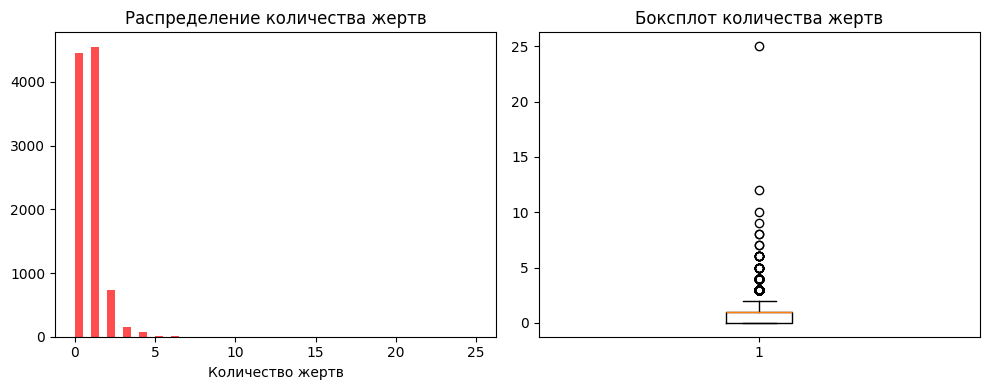

In [23]:
# Создание целевой переменной
gun_data['total_victims'] = gun_data['n_killed'] + gun_data['n_injured']

# Удаление неиспользуемых столбцов
used_columns_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county', 'total_victims']
gun_data_reduced = gun_data[used_columns_reg].copy()

# Удаление строк с пропущенными значениями
gun_data_clean = gun_data_reduced.dropna()

# Ограничим данные для ускорения (опционально)
if gun_data_clean.shape[0] > 10000:
    gun_data_clean = gun_data_clean.sample(n=10000, random_state=42, replace=False)

print(f"Размер датасета для регрессии: {gun_data_clean.shape}")
print(f"Распределение целевой переменной:")
print(gun_data_clean['total_victims'].describe())

# Визуализация распределения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(gun_data_clean['total_victims'], bins=50, alpha=0.7, color='red')
plt.title('Распределение количества жертв')
plt.xlabel('Количество жертв')

plt.subplot(1, 2, 2)
plt.boxplot(gun_data_clean['total_victims'])
plt.title('Боксплот количества жертв')
plt.tight_layout()
plt.show()

# Блок 4: Предобработка данных для классификации (Anime)

Размер датасета для классификации: (5000, 5)
Распределение типов аниме:
type
TV         1706
OVA        1492
Movie      1022
Special     780
Name: count, dtype: int64


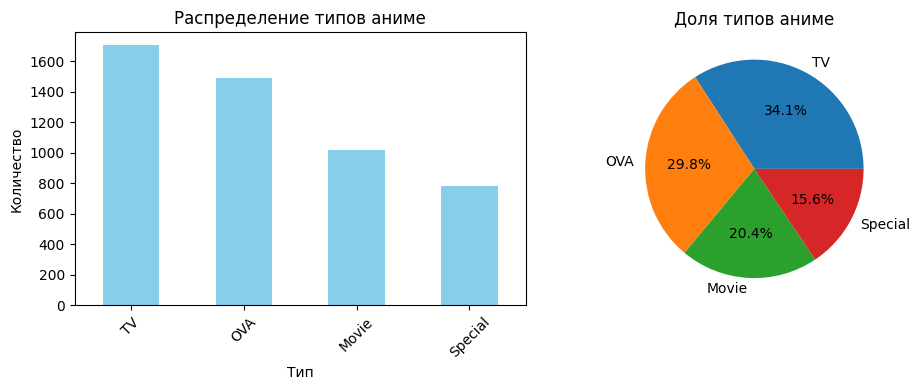

In [24]:
# Удаление неиспользуемых столбцов
used_columns_clf = ['episodes', 'rating', 'members', 'genre', 'type']
anime_data_reduced = anime_data[used_columns_clf].copy()

# Удаление строк с пропущенными значениями
anime_data_clean = anime_data_reduced.dropna()

# Оставляем основные типы
main_types = ['TV', 'Movie', 'OVA', 'Special']
anime_data_clean = anime_data_clean[anime_data_clean['type'].isin(main_types)]

# Ограничим данные для ускорения (опционально)
if anime_data_clean.shape[0] > 5000:
    anime_data_clean = anime_data_clean.sample(n=5000, random_state=42, replace=False)

print(f"Размер датасета для классификации: {anime_data_clean.shape}")
print(f"Распределение типов аниме:")
type_counts = anime_data_clean['type'].value_counts()
print(type_counts)

# Визуализация распределения классов
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
type_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение типов аниме')
plt.xlabel('Тип')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
plt.title('Доля типов аниме')
plt.tight_layout()
plt.show()

# Блок 5: Подготовка признаков для регрессии

In [25]:
# Разделение на признаки и целевую переменную
features_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county']
target_reg = 'total_victims'

X_reg = gun_data_clean[features_reg].copy()
y_reg = gun_data_clean[target_reg]

# Кодирование категориальных признаков для случайного леса
label_encoder_state = LabelEncoder()
label_encoder_city = LabelEncoder()

X_reg['state_encoded'] = label_encoder_state.fit_transform(X_reg['state'].fillna('Unknown'))
X_reg['city_encoded'] = label_encoder_city.fit_transform(X_reg['city_or_county'].fillna('Unknown'))

# Выбираем закодированные признаки
X_reg_encoded = X_reg[['latitude', 'longitude', 'n_guns_involved', 'state_encoded', 'city_encoded']]

# Заполнение пропущенных значений
imputer_reg = SimpleImputer(strategy='median')
X_reg_imputed = pd.DataFrame(imputer_reg.fit_transform(X_reg_encoded), 
                            columns=X_reg_encoded.columns)

# Для случайного леса масштабирование не обязательно, но можем оставить
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg_imputed)

# Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

print(f"Размеры выборок для регрессии:")
print(f"Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Количество признаков: {X_train_reg.shape[1]}")

Размеры выборок для регрессии:
Train: (8000, 5), Test: (2000, 5)
Количество признаков: 5


# Блок 6: Подготовка признаков для классификации

In [26]:
# Разделение на признаки и целевую переменную
features_clf = ['episodes', 'rating', 'members', 'genre']
target_clf = 'type'

X_clf = anime_data_clean[features_clf].copy()
y_clf = anime_data_clean[target_clf]

# Обработка признаков
X_clf['episodes'] = pd.to_numeric(X_clf['episodes'], errors='coerce')
X_clf['main_genre'] = X_clf['genre'].str.split(',').str[0].fillna('Unknown')

# Кодирование категориальных признаков
label_encoder_genre = LabelEncoder()
X_clf['main_genre_encoded'] = label_encoder_genre.fit_transform(X_clf['main_genre'])

# Выбор финальных признаков
X_clf_processed = X_clf[['episodes', 'rating', 'members', 'main_genre_encoded']]

# Заполнение пропущенных значений
imputer_clf = SimpleImputer(strategy='median')
X_clf_imputed = pd.DataFrame(imputer_clf.fit_transform(X_clf_processed), 
                            columns=X_clf_processed.columns)

# Для случайного леса масштабирование не обязательно
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf_imputed)

# Кодирование целевой переменной
label_encoder_target = LabelEncoder()
y_clf_encoded = label_encoder_target.fit_transform(y_clf)

# Разделение на train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

print(f"Размеры выборок для классификации:")
print(f"Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"Количество классов: {len(label_encoder_target.classes_)}")
print(f"Классы: {label_encoder_target.classes_}")

Размеры выборок для классификации:
Train: (4000, 4), Test: (1000, 4)
Количество классов: 4
Классы: ['Movie' 'OVA' 'Special' 'TV']


# Блок 7: Бейзлайн модели случайного леса

In [27]:
# Случайный лес для регрессии
rf_reg_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_baseline.fit(X_train_reg, y_train_reg)
y_pred_reg_baseline = rf_reg_baseline.predict(X_test_reg)

# Случайный лес для классификации
rf_clf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf_baseline.fit(X_train_clf, y_train_clf)
y_pred_clf_baseline = rf_clf_baseline.predict(X_test_clf)

print("Бейзлайн модели случайного леса обучены")

Бейзлайн модели случайного леса обучены


# Блок 8: Оценка качества бейзлайн моделей


--- СЛУЧАЙНЫЙ ЛЕС РЕГРЕССИИ (Gun Violence) ---
MAE: 0.5626
RMSE: 0.7615
R² Score: -0.0076

Количество деревьев: 100
Глубина деревьев (средняя): 41.3

--- СЛУЧАЙНЫЙ ЛЕС КЛАССИФИКАЦИИ (Anime) ---
Accuracy: 0.7170
Precision: 0.7109
Recall: 0.7170
F1-Score: 0.7134

Количество деревьев: 100
Глубина деревьев (средняя): 24.9

Classification Report:
              precision    recall  f1-score   support

       Movie       0.60      0.65      0.63       204
         OVA       0.66      0.66      0.66       299
     Special       0.43      0.37      0.40       156
          TV       0.94      0.96      0.95       341

    accuracy                           0.72      1000
   macro avg       0.66      0.66      0.66      1000
weighted avg       0.71      0.72      0.71      1000



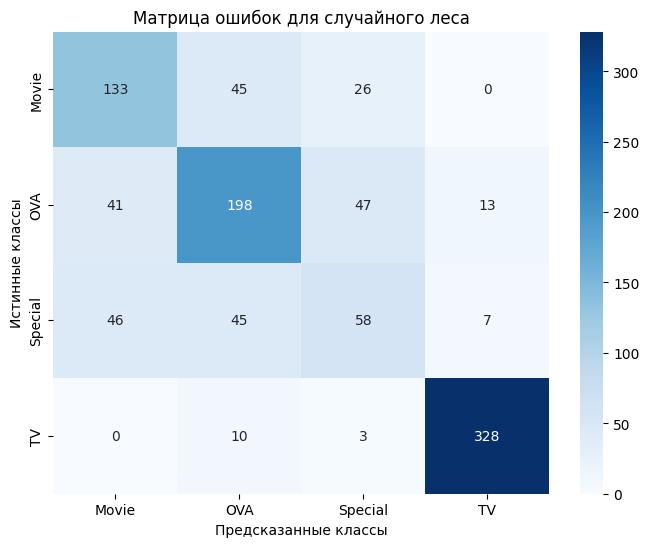

In [28]:
print("\n--- СЛУЧАЙНЫЙ ЛЕС РЕГРЕССИИ (Gun Violence) ---")
mae_baseline = mean_absolute_error(y_test_reg, y_pred_reg_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_baseline))
r2_baseline = r2_score(y_test_reg, y_pred_reg_baseline)

print(f"MAE: {mae_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"R² Score: {r2_baseline:.4f}")

print(f"\nКоличество деревьев: {rf_reg_baseline.n_estimators}")
print(f"Глубина деревьев (средняя): {np.mean([tree.tree_.max_depth for tree in rf_reg_baseline.estimators_]):.1f}")

print("\n--- СЛУЧАЙНЫЙ ЛЕС КЛАССИФИКАЦИИ (Anime) ---")
accuracy_baseline = accuracy_score(y_test_clf, y_pred_clf_baseline)
precision_baseline = precision_score(y_test_clf, y_pred_clf_baseline, average='weighted')
recall_baseline = recall_score(y_test_clf, y_pred_clf_baseline, average='weighted')
f1_baseline = f1_score(y_test_clf, y_pred_clf_baseline, average='weighted')

print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1-Score: {f1_baseline:.4f}")

print(f"\nКоличество деревьев: {rf_clf_baseline.n_estimators}")
print(f"Глубина деревьев (средняя): {np.mean([tree.tree_.max_depth for tree in rf_clf_baseline.estimators_]):.1f}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_baseline, 
                          target_names=label_encoder_target.classes_))

# Матрица ошибок
cm = confusion_matrix(y_test_clf, y_pred_clf_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder_target.classes_, 
            yticklabels=label_encoder_target.classes_)
plt.title('Матрица ошибок для случайного леса')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

# Формулировка гипотез для улучшения

## ГИПОТЕЗЫ ДЛЯ РЕГРЕССИИ:
1. Увеличение количества деревьев (n_estimators)
2. Оптимизация глубины деревьев (max_depth)
3. Настройка минимального количества образцов для разделения (min_samples_split)
4. Настройка минимального количества образцов в листе (min_samples_leaf)
5. Оптимизация количества признаков для рассмотрения (max_features)
6. Использование бутстрэппинга или нет (bootstrap)

## ГИПОТЕЗЫ ДЛЯ КЛАССИФИКАЦИИ:
1. Оптимизация количества деревьев
2. Настройка глубины деревьев
3. Балансировка классов (class_weight)
4. Настройка критерия разделения (gini/entropy)
5. Оптимизация параметров выборки признаков
6. Использование OOB-оценки (oob_score)

## ОБЩИЕ ГИПОТЕЗЫ:
1. Отбор важных признаков на основе feature importance
2. Использование кросс-валидации для подбора гиперпараметров
3. Применение RandomizedSearchCV для поиска по большому пространству параметров
4. Сравнение с Gradient Boosting методами


# Блок 9: Проверка гипотез - подбор гиперпараметров для регрессии

Подбор гиперпараметров для случайного леса регрессии...
Лучшие параметры для случайного леса регрессии: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': True}
Лучший RMSE: 0.8236


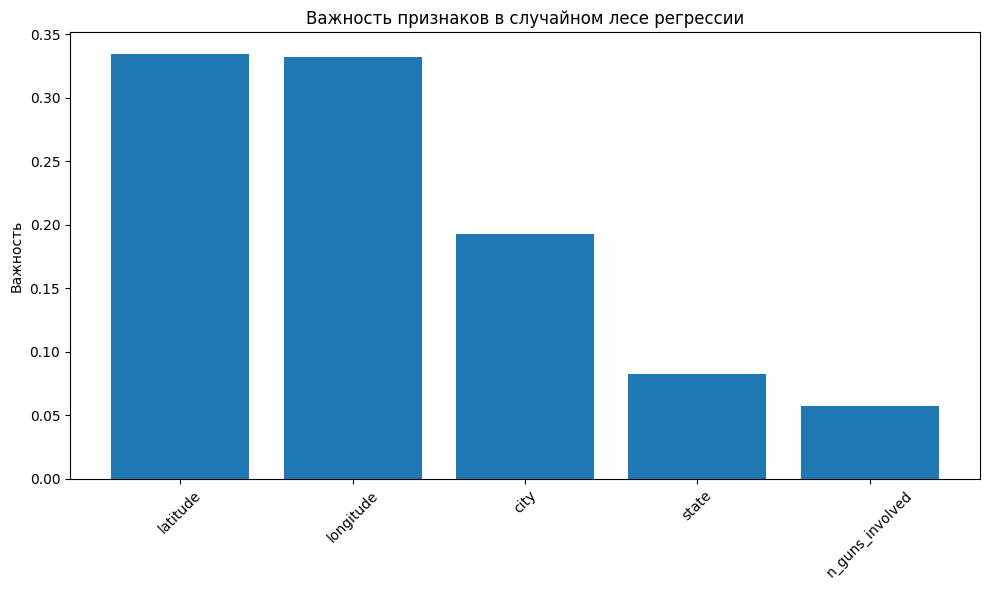

In [29]:
# Используем RandomizedSearchCV для более быстрого поиска
param_dist_reg = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

print("Подбор гиперпараметров для случайного леса регрессии...")
rf_reg_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_reg,
    n_iter=20,  # Количество итераций
    cv=3,       # 3-fold кросс-валидация
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_reg_random.fit(X_train_reg, y_train_reg)

print(f"Лучшие параметры для случайного леса регрессии: {rf_reg_random.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-rf_reg_random.best_score_):.4f}")

# Проверка важности признаков
feature_importance_reg = rf_reg_random.best_estimator_.feature_importances_
feature_names_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city']

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(feature_importance_reg)[::-1]
plt.bar(range(len(feature_importance_reg)), feature_importance_reg[sorted_idx])
plt.xticks(range(len(feature_importance_reg)), [feature_names_reg[i] for i in sorted_idx], rotation=45)
plt.title('Важность признаков в случайном лесе регрессии')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

# Блок 10: Проверка гипотез - подбор гиперпараметров для классификации

Подбор гиперпараметров для случайного леса классификации...
Лучшие параметры для случайного леса классификации: {'n_estimators': 50, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40, 'criterion': 'gini', 'class_weight': None}
Лучшая точность: 0.7392


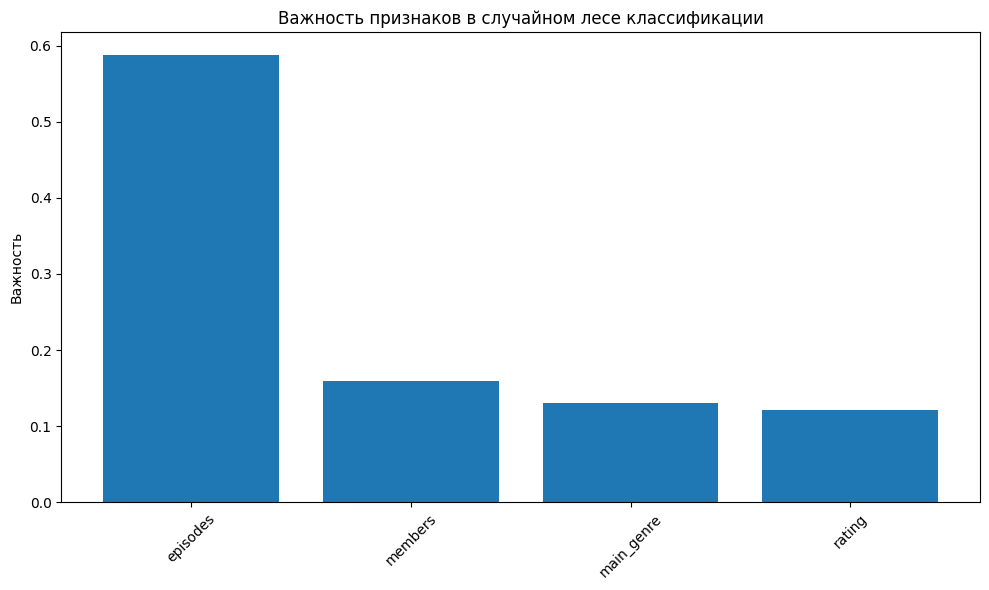

In [30]:
# Используем RandomizedSearchCV для более быстрого поиска
param_dist_clf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

print("Подбор гиперпараметров для случайного леса классификации...")
rf_clf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_clf,
    n_iter=20,  # Количество итераций
    cv=3,       # 3-fold кросс-валидация
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_clf_random.fit(X_train_clf, y_train_clf)

print(f"Лучшие параметры для случайного леса классификации: {rf_clf_random.best_params_}")
print(f"Лучшая точность: {rf_clf_random.best_score_:.4f}")

# Проверка важности признаков
feature_importance_clf = rf_clf_random.best_estimator_.feature_importances_
feature_names_clf = ['episodes', 'rating', 'members', 'main_genre']

plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(feature_importance_clf)[::-1]
plt.bar(range(len(feature_importance_clf)), feature_importance_clf[sorted_idx])
plt.xticks(range(len(feature_importance_clf)), [feature_names_clf[i] for i in sorted_idx], rotation=45)
plt.title('Важность признаков в случайном лесе классификации')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

# Блок 11: Улучшенные модели с подобранными гиперпараметрами

In [31]:
# Улучшенная модель регрессии
rf_reg_improved = rf_reg_random.best_estimator_
y_pred_reg_improved = rf_reg_improved.predict(X_test_reg)

# Улучшенная модель классификации
rf_clf_improved = rf_clf_random.best_estimator_
y_pred_clf_improved = rf_clf_improved.predict(X_test_clf)

print("Улучшенные модели случайного леса обучены")

Улучшенные модели случайного леса обучены


# Блок 12: Оценка улучшенных моделей

In [32]:
print("\n--- РЕГРЕССИЯ (Random Forest) - УЛУЧШЕННАЯ ---")
mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_improved))
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print(f"MAE: {mae_improved:.4f} (было: {mae_baseline:.4f})")
print(f"RMSE: {rmse_improved:.4f} (было: {rmse_baseline:.4f})")
print(f"R² Score: {r2_improved:.4f} (было: {r2_baseline:.4f})")

print(f"\nКоличество деревьев: {rf_reg_improved.n_estimators}")
print(f"Глубина деревьев: {rf_reg_improved.max_depth}")

print("\n--- КЛАССИФИКАЦИЯ (Random Forest) - УЛУЧШЕННАЯ ---")
accuracy_improved = accuracy_score(y_test_clf, y_pred_clf_improved)
precision_improved = precision_score(y_test_clf, y_pred_clf_improved, average='weighted')
recall_improved = recall_score(y_test_clf, y_pred_clf_improved, average='weighted')
f1_improved = f1_score(y_test_clf, y_pred_clf_improved, average='weighted')

print(f"Accuracy: {accuracy_improved:.4f} (было: {accuracy_baseline:.4f})")
print(f"Precision: {precision_improved:.4f} (было: {precision_baseline:.4f})")
print(f"Recall: {recall_improved:.4f} (было: {recall_baseline:.4f})")
print(f"F1-Score: {f1_improved:.4f} (было: {f1_baseline:.4f})")

print(f"\nКоличество деревьев: {rf_clf_improved.n_estimators}")
print(f"Глубина деревьев: {rf_clf_improved.max_depth}")

print("\nClassification Report (улучшенная):")
print(classification_report(y_test_clf, y_pred_clf_improved, 
                          target_names=label_encoder_target.classes_))


--- РЕГРЕССИЯ (Random Forest) - УЛУЧШЕННАЯ ---
MAE: 0.5409 (было: 0.5626)
RMSE: 0.7225 (было: 0.7615)
R² Score: 0.0928 (было: -0.0076)

Количество деревьев: 300
Глубина деревьев: 40

--- КЛАССИФИКАЦИЯ (Random Forest) - УЛУЧШЕННАЯ ---
Accuracy: 0.7400 (было: 0.7170)
Precision: 0.7330 (было: 0.7109)
Recall: 0.7400 (было: 0.7170)
F1-Score: 0.7323 (было: 0.7134)

Количество деревьев: 50
Глубина деревьев: 40

Classification Report (улучшенная):
              precision    recall  f1-score   support

       Movie       0.61      0.77      0.68       204
         OVA       0.71      0.67      0.69       299
     Special       0.48      0.33      0.39       156
          TV       0.95      0.97      0.96       341

    accuracy                           0.74      1000
   macro avg       0.69      0.69      0.68      1000
weighted avg       0.73      0.74      0.73      1000



# Блок 13: Сравнение результатов улучшенных моделей

In [33]:
print("\nУЛУЧШЕНИЯ РЕГРЕССИИ:")
improvement_mae = ((mae_baseline - mae_improved) / mae_baseline) * 100
improvement_rmse = ((rmse_baseline - rmse_improved) / rmse_baseline) * 100
improvement_r2 = ((r2_improved - r2_baseline) / abs(r2_baseline)) * 100

print(f"Улучшение MAE: {improvement_mae:+.2f}%")
print(f"Улучшение RMSE: {improvement_rmse:+.2f}%") 
print(f"Улучшение R²: {improvement_r2:+.2f}%")

print("\nУЛУЧШЕНИЯ КЛАССИФИКАЦИИ:")
improvement_accuracy = ((accuracy_improved - accuracy_baseline) / accuracy_baseline) * 100
improvement_f1 = ((f1_improved - f1_baseline) / f1_baseline) * 100

print(f"Улучшение Accuracy: {improvement_accuracy:+.2f}%")
print(f"Улучшение F1-Score: {improvement_f1:+.2f}%")


УЛУЧШЕНИЯ РЕГРЕССИИ:
Улучшение MAE: +3.87%
Улучшение RMSE: +5.11%
Улучшение R²: +1317.33%

УЛУЧШЕНИЯ КЛАССИФИКАЦИИ:
Улучшение Accuracy: +3.21%
Улучшение F1-Score: +2.65%


# Блок 14: Реализация собственного случайного леса для регрессии

In [34]:
class MyRandomForestRegressor:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, 
                 min_samples_leaf=1, max_features='auto', bootstrap=True, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.estimators_ = []
        self.feature_importances_ = None
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _bootstrap_sample(self, X, y):
        """Создание бутстрэп выборки"""
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]
    
    def _get_feature_subset(self, n_features):
        """Выбор подмножества признаков"""
        if isinstance(self.max_features, int):
            n_selected = min(self.max_features, n_features)
        elif isinstance(self.max_features, float):
            n_selected = max(1, int(self.max_features * n_features))
        elif self.max_features == 'sqrt':
            n_selected = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            n_selected = int(np.log2(n_features))
        else:  # 'auto'
            n_selected = n_features
        
        features = np.random.choice(n_features, n_selected, replace=False)
        return features
    
    def _build_tree(self, X, y, depth=0):
        """Построение одного решающего дерева (упрощенное)"""
        n_samples, n_features = X.shape
        
        # Условия остановки
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return {'value': np.mean(y), 'is_leaf': True}
        
        # Выбор случайного подмножества признаков
        selected_features = self._get_feature_subset(n_features)
        X_selected = X[:, selected_features]
        
        # Поиск наилучшего разделения (упрощенный)
        best_feature = None
        best_threshold = None
        best_mse = np.inf
        
        for feature_idx in range(len(selected_features)):
            feature_values = X_selected[:, feature_idx]
            thresholds = np.unique(feature_values)
            
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                left_mse = np.mean((y[left_mask] - np.mean(y[left_mask])) ** 2)
                right_mse = np.mean((y[right_mask] - np.mean(y[right_mask])) ** 2)
                weighted_mse = (np.sum(left_mask) * left_mse + np.sum(right_mask) * right_mse) / n_samples
                
                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = selected_features[feature_idx]
                    best_threshold = threshold
        
        if best_feature is None:
            return {'value': np.mean(y), 'is_leaf': True}
        
        # Разделение данных
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Создание узла
        node = {
            'feature': best_feature,
            'threshold': best_threshold,
            'is_leaf': False,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }
        
        return node
    
    def fit(self, X, y):
        """Обучение случайного леса"""
        n_samples, n_features = X.shape
        self.estimators_ = []
        self.feature_importances_ = np.zeros(n_features)
        
        print(f"Обучение случайного леса с {self.n_estimators} деревьями...")
        
        for i in range(self.n_estimators):
            if i % 10 == 0:
                print(f"  Построено {i}/{self.n_estimators} деревьев...")
            
            # Бутстрэп выборка
            if self.bootstrap:
                X_bootstrap, y_bootstrap = self._bootstrap_sample(X, y)
            else:
                X_bootstrap, y_bootstrap = X, y
            
            # Построение дерева
            tree = self._build_tree(X_bootstrap, y_bootstrap)
            self.estimators_.append(tree)
        
        print("Обучение завершено")
        return self
    
    def _predict_tree(self, x, tree):
        """Предсказание одним деревом"""
        if tree['is_leaf']:
            return tree['value']
        
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_tree(x, tree['left'])
        else:
            return self._predict_tree(x, tree['right'])
    
    def predict(self, X):
        """Предсказание случайным лесом"""
        predictions = []
        for x in X:
            tree_preds = [self._predict_tree(x, tree) for tree in self.estimators_]
            predictions.append(np.mean(tree_preds))
        return np.array(predictions)

# Тестирование собственного случайного леса (упрощенная версия)
print("Обучаем собственный случайный лес для регрессии...")
# Используем меньше деревьев для скорости
my_rf_reg = MyRandomForestRegressor(
    n_estimators=20, 
    max_depth=5, 
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)
my_rf_reg.fit(X_train_reg[:500], y_train_reg.values[:500])  # Ограничим данные для скорости
y_pred_my_reg = my_rf_reg.predict(X_test_reg[:100])  # Ограничим тестовые данные

print("Собственный случайный лес для регрессии обучен")

Обучаем собственный случайный лес для регрессии...
Обучение случайного леса с 20 деревьями...
  Построено 0/20 деревьев...
  Построено 10/20 деревьев...
Обучение завершено
Собственный случайный лес для регрессии обучен


# Блок 15: Реализация собственного случайного леса для классификации

In [35]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, 
                 min_samples_leaf=1, max_features='auto', bootstrap=True, 
                 criterion='gini', random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.criterion = criterion
        self.random_state = random_state
        self.estimators_ = []
        self.classes_ = None
        self.feature_importances_ = None
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _bootstrap_sample(self, X, y):
        """Создание бутстрэп выборки"""
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]
    
    def _get_feature_subset(self, n_features):
        """Выбор подмножества признаков"""
        if isinstance(self.max_features, int):
            n_selected = min(self.max_features, n_features)
        elif isinstance(self.max_features, float):
            n_selected = max(1, int(self.max_features * n_features))
        elif self.max_features == 'sqrt':
            n_selected = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            n_selected = int(np.log2(n_features))
        else:  # 'auto'
            n_selected = n_features
        
        features = np.random.choice(n_features, n_selected, replace=False)
        return features
    
    def _calculate_impurity(self, y):
        """Вычисление неопределенности"""
        if len(y) == 0:
            return 0
        
        classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        
        if self.criterion == 'gini':
            return 1 - np.sum(probabilities ** 2)
        else:  # entropy
            return -np.sum(probabilities * np.log2(probabilities + 1e-10))
    
    def _calculate_information_gain(self, y, y_left, y_right):
        """Вычисление информационного выигрыша"""
        total_impurity = self._calculate_impurity(y)
        left_impurity = self._calculate_impurity(y_left)
        right_impurity = self._calculate_impurity(y_right)
        
        n = len(y)
        n_left = len(y_left)
        n_right = len(y_right)
        
        weighted_impurity = (n_left / n) * left_impurity + (n_right / n) * right_impurity
        return total_impurity - weighted_impurity
    
    def _build_tree(self, X, y, depth=0):
        """Построение одного решающего дерева (упрощенное)"""
        n_samples, n_features = X.shape
        
        # Условия остановки
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            classes, counts = np.unique(y, return_counts=True)
            return {'value': classes[np.argmax(counts)], 'is_leaf': True, 'class_distribution': counts}
        
        # Выбор случайного подмножества признаков
        selected_features = self._get_feature_subset(n_features)
        X_selected = X[:, selected_features]
        
        # Поиск наилучшего разделения
        best_feature = None
        best_threshold = None
        best_gain = -1
        
        for feature_idx in range(len(selected_features)):
            feature_values = X_selected[:, feature_idx]
            thresholds = np.unique(feature_values)
            
            for threshold in thresholds:
                left_mask = feature_values <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                gain = self._calculate_information_gain(y, y[left_mask], y[right_mask])
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = selected_features[feature_idx]
                    best_threshold = threshold
        
        if best_feature is None:
            classes, counts = np.unique(y, return_counts=True)
            return {'value': classes[np.argmax(counts)], 'is_leaf': True, 'class_distribution': counts}
        
        # Разделение данных
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Создание узла
        node = {
            'feature': best_feature,
            'threshold': best_threshold,
            'is_leaf': False,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }
        
        return node
    
    def fit(self, X, y):
        """Обучение случайного леса"""
        n_samples, n_features = X.shape
        self.estimators_ = []
        self.classes_ = np.unique(y)
        self.feature_importances_ = np.zeros(n_features)
        
        print(f"Обучение случайного леса с {self.n_estimators} деревьями...")
        
        for i in range(self.n_estimators):
            if i % 10 == 0:
                print(f"  Построено {i}/{self.n_estimators} деревьев...")
            
            # Бутстрэп выборка
            if self.bootstrap:
                X_bootstrap, y_bootstrap = self._bootstrap_sample(X, y)
            else:
                X_bootstrap, y_bootstrap = X, y
            
            # Построение дерева
            tree = self._build_tree(X_bootstrap, y_bootstrap)
            self.estimators_.append(tree)
        
        print("Обучение завершено")
        return self
    
    def _predict_tree(self, x, tree):
        """Предсказание одним деревом"""
        if tree['is_leaf']:
            return tree['value']
        
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_tree(x, tree['left'])
        else:
            return self._predict_tree(x, tree['right'])
    
    def predict(self, X):
        """Предсказание случайным лесом"""
        predictions = []
        for x in X:
            tree_preds = [self._predict_tree(x, tree) for tree in self.estimators_]
            # Голосование большинством
            unique, counts = np.unique(tree_preds, return_counts=True)
            predictions.append(unique[np.argmax(counts)])
        return np.array(predictions)

# Тестирование собственного случайного леса (упрощенная версия)
print("Обучаем собственный случайный лес для классификации...")
# Используем меньше деревьев и ограничим данные для скорости
max_samples = min(500, X_train_clf.shape[0])
X_train_clf_small = X_train_clf[:max_samples]
y_train_clf_small = y_train_clf[:max_samples]
X_test_clf_small = X_test_clf[:100]
y_test_clf_small = y_test_clf[:100]

my_rf_clf = MyRandomForestClassifier(
    n_estimators=20, 
    max_depth=5, 
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    bootstrap=True,
    criterion='gini',
    random_state=42
)
my_rf_clf.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf = my_rf_clf.predict(X_test_clf_small)

print("Собственный случайный лес для классификации обучен")

Обучаем собственный случайный лес для классификации...
Обучение случайного леса с 20 деревьями...
  Построено 0/20 деревьев...
  Построено 10/20 деревьев...
Обучение завершено
Собственный случайный лес для классификации обучен


# Блок 16: Оценка собственных реализаций

In [36]:
print("\n--- СОБСТВЕННЫЙ СЛУЧАЙНЫЙ ЛЕС РЕГРЕССИИ ---")
# Оцениваем на ограниченных тестовых данных
mae_my_reg = mean_absolute_error(y_test_reg[:100], y_pred_my_reg)
rmse_my_reg = np.sqrt(mean_squared_error(y_test_reg[:100], y_pred_my_reg))
r2_my_reg = r2_score(y_test_reg[:100], y_pred_my_reg)

print(f"MAE: {mae_my_reg:.4f} (sklearn baseline на полных данных: {mae_baseline:.4f})")
print(f"RMSE: {rmse_my_reg:.4f} (sklearn baseline: {rmse_baseline:.4f})")
print(f"R² Score: {r2_my_reg:.4f} (sklearn baseline: {r2_baseline:.4f})")

print("\n--- СОБСТВЕННЫЙ СЛУЧАЙНЫЙ ЛЕС КЛАССИФИКАЦИИ ---")
accuracy_my_clf = accuracy_score(y_test_clf_small, y_pred_my_clf)
print(f"Accuracy: {accuracy_my_clf:.4f} (sklearn baseline на полных данных: {accuracy_baseline:.4f})")

# Переобучим sklearn на тех же данных для честного сравнения
rf_clf_small = RandomForestClassifier(
    n_estimators=20, 
    max_depth=5, 
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)
rf_clf_small.fit(X_train_clf_small, y_train_clf_small)
y_pred_sklearn_small = rf_clf_small.predict(X_test_clf_small)
accuracy_sklearn_small = accuracy_score(y_test_clf_small, y_pred_sklearn_small)
print(f"Sklearn Random Forest на тех же данных: {accuracy_sklearn_small:.4f}")


--- СОБСТВЕННЫЙ СЛУЧАЙНЫЙ ЛЕС РЕГРЕССИИ ---
MAE: 0.5221 (sklearn baseline на полных данных: 0.5626)
RMSE: 0.7540 (sklearn baseline: 0.7615)
R² Score: -0.0045 (sklearn baseline: -0.0076)

--- СОБСТВЕННЫЙ СЛУЧАЙНЫЙ ЛЕС КЛАССИФИКАЦИИ ---
Accuracy: 0.6900 (sklearn baseline на полных данных: 0.7170)
Sklearn Random Forest на тех же данных: 0.6900


# Блок 17: Применение улучшений к собственным реализациям

In [37]:
# Используем лучшие параметры из RandomizedSearchCV
best_params_rf_reg = rf_reg_random.best_params_
best_params_rf_clf = rf_clf_random.best_params_

print(f"Лучшие параметры для случайного леса регрессии: {best_params_rf_reg}")
print(f"Лучшие параметры для случайного леса классификации: {best_params_rf_clf}")

# Улучшенная собственная модель регрессии
print("\nОбучаем улучшенный собственный случайный лес для регрессии...")
my_rf_reg_improved = MyRandomForestRegressor(
    n_estimators=min(20, best_params_rf_reg.get('n_estimators', 20)),  # Ограничим для скорости
    max_depth=best_params_rf_reg.get('max_depth', 5),
    min_samples_split=best_params_rf_reg.get('min_samples_split', 10),
    min_samples_leaf=best_params_rf_reg.get('min_samples_leaf', 5),
    max_features=best_params_rf_reg.get('max_features', 'sqrt'),
    bootstrap=best_params_rf_reg.get('bootstrap', True),
    random_state=42
)
my_rf_reg_improved.fit(X_train_reg[:500], y_train_reg.values[:500])  # Ограничим данные
y_pred_my_reg_improved = my_rf_reg_improved.predict(X_test_reg[:100])

# Улучшенная собственная модель классификации
print("\nОбучаем улучшенный собственный случайный лес для классификации...")
my_rf_clf_improved = MyRandomForestClassifier(
    n_estimators=min(20, best_params_rf_clf.get('n_estimators', 20)),
    max_depth=best_params_rf_clf.get('max_depth', 5),
    min_samples_split=best_params_rf_clf.get('min_samples_split', 10),
    min_samples_leaf=best_params_rf_clf.get('min_samples_leaf', 5),
    max_features=best_params_rf_clf.get('max_features', 'sqrt'),
    bootstrap=best_params_rf_clf.get('bootstrap', True),
    criterion=best_params_rf_clf.get('criterion', 'gini'),
    random_state=42
)
my_rf_clf_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf_improved = my_rf_clf_improved.predict(X_test_clf_small)

print("Улучшенные собственные модели случайного леса обучены")

Лучшие параметры для случайного леса регрессии: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': True}
Лучшие параметры для случайного леса классификации: {'n_estimators': 50, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 40, 'criterion': 'gini', 'class_weight': None}

Обучаем улучшенный собственный случайный лес для регрессии...
Обучение случайного леса с 20 деревьями...
  Построено 0/20 деревьев...
  Построено 10/20 деревьев...
Обучение завершено

Обучаем улучшенный собственный случайный лес для классификации...
Обучение случайного леса с 20 деревьями...
  Построено 0/20 деревьев...
  Построено 10/20 деревьев...
Обучение завершено
Улучшенные собственные модели случайного леса обучены


# Блок 18: Финальное сравнение всех моделей

In [38]:
# Вычисление метрик для улучшенных собственных реализаций
mae_my_reg_improved = mean_absolute_error(y_test_reg[:100], y_pred_my_reg_improved)
rmse_my_reg_improved = np.sqrt(mean_squared_error(y_test_reg[:100], y_pred_my_reg_improved))
r2_my_reg_improved = r2_score(y_test_reg[:100], y_pred_my_reg_improved)
accuracy_my_clf_improved = accuracy_score(y_test_clf_small, y_pred_my_clf_improved)

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)")
print("="*70)
results_reg = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My RF Baseline', 'My RF Improved'],
    'MAE': [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved],
    'RMSE': [rmse_baseline, rmse_improved, rmse_my_reg, rmse_my_reg_improved],
    'R²': [r2_baseline, r2_improved, r2_my_reg, r2_my_reg_improved]
})
print(results_reg.round(4))

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)")
print("="*70)

# Для классификации сравним на ограниченных данных
rf_clf_small_improved = RandomForestClassifier(
    n_estimators=min(20, best_params_rf_clf.get('n_estimators', 20)),
    max_depth=best_params_rf_clf.get('max_depth', 5),
    min_samples_split=best_params_rf_clf.get('min_samples_split', 10),
    min_samples_leaf=best_params_rf_clf.get('min_samples_leaf', 5),
    max_features=best_params_rf_clf.get('max_features', 'sqrt'),
    bootstrap=best_params_rf_clf.get('bootstrap', True),
    criterion=best_params_rf_clf.get('criterion', 'gini'),
    random_state=42
)
rf_clf_small_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_sklearn_small_improved = rf_clf_small_improved.predict(X_test_clf_small)
accuracy_sklearn_small_improved = accuracy_score(y_test_clf_small, y_pred_sklearn_small_improved)

results_clf = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My RF Baseline', 'My RF Improved'],
    'Accuracy': [accuracy_sklearn_small, accuracy_sklearn_small_improved, 
                accuracy_my_clf, accuracy_my_clf_improved]
})
print(results_clf.round(4))


ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)
              Model     MAE    RMSE      R²
0  Sklearn Baseline  0.5626  0.7615 -0.0076
1  Sklearn Improved  0.5409  0.7225  0.0928
2    My RF Baseline  0.5221  0.7540 -0.0045
3    My RF Improved  0.5713  0.7906 -0.1045

ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)
              Model  Accuracy
0  Sklearn Baseline      0.69
1  Sklearn Improved      0.72
2    My RF Baseline      0.69
3    My RF Improved      0.72


# Блок 19: Визуализация важности признаков и сравнения моделей

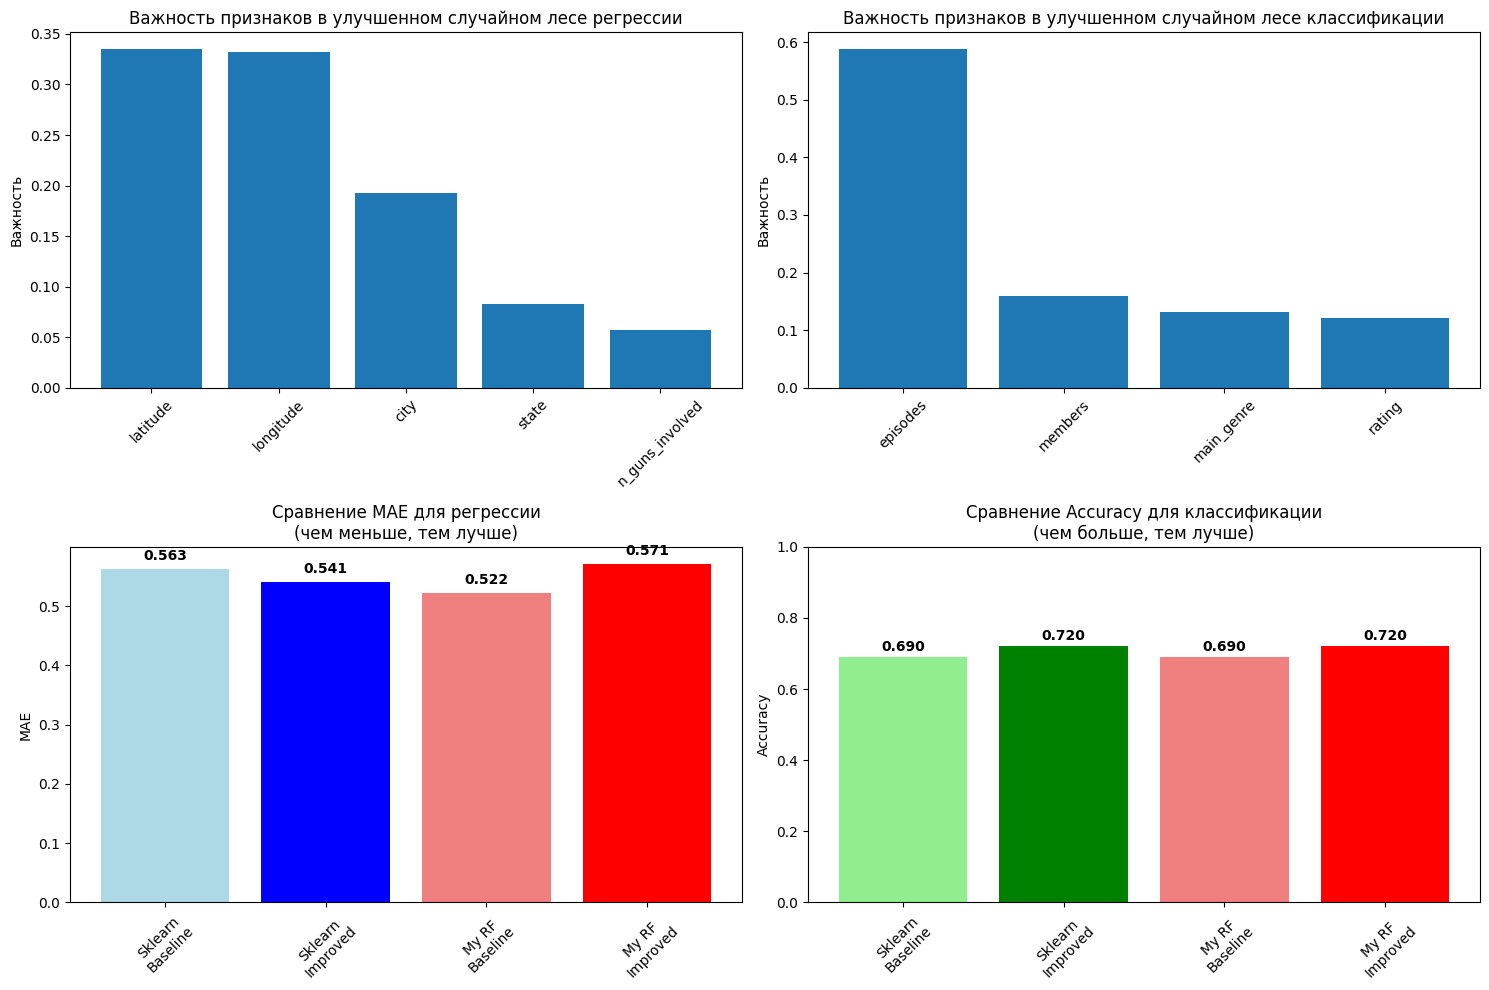

In [39]:
# 1. Важность признаков для улучшенного случайного леса регрессии
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
if hasattr(rf_reg_improved, 'feature_importances_'):
    feature_importance_reg = rf_reg_improved.feature_importances_
    sorted_idx_reg = np.argsort(feature_importance_reg)[::-1]
    plt.bar(range(len(feature_importance_reg)), feature_importance_reg[sorted_idx_reg])
    plt.xticks(range(len(feature_importance_reg)), 
               [feature_names_reg[i] for i in sorted_idx_reg], rotation=45)
    plt.title('Важность признаков в улучшенном случайном лесе регрессии')
    plt.ylabel('Важность')

# 2. Важность признаков для улучшенного случайного леса классификации
plt.subplot(2, 2, 2)
if hasattr(rf_clf_improved, 'feature_importances_'):
    feature_importance_clf = rf_clf_improved.feature_importances_
    sorted_idx_clf = np.argsort(feature_importance_clf)[::-1]
    plt.bar(range(len(feature_importance_clf)), feature_importance_clf[sorted_idx_clf])
    plt.xticks(range(len(feature_importance_clf)), 
               [feature_names_clf[i] for i in sorted_idx_clf], rotation=45)
    plt.title('Важность признаков в улучшенном случайном лесе классификации')
    plt.ylabel('Важность')

# 3. Сравнение метрик регрессии
plt.subplot(2, 2, 3)
models_reg = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My RF\nBaseline', 'My RF\nImproved']
mae_scores = [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved]
colors = ['lightblue', 'blue', 'lightcoral', 'red']
bars = plt.bar(models_reg, mae_scores, color=colors)
plt.title('Сравнение MAE для регрессии\n(чем меньше, тем лучше)')
plt.ylabel('MAE')
plt.xticks(rotation=45)
for i, v in enumerate(mae_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Сравнение метрик классификации
plt.subplot(2, 2, 4)
models_clf = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My RF\nBaseline', 'My RF\nImproved']
accuracy_scores = [accuracy_sklearn_small, accuracy_sklearn_small_improved, 
                   accuracy_my_clf, accuracy_my_clf_improved]
colors = ['lightgreen', 'green', 'lightcoral', 'red']
bars = plt.bar(models_clf, accuracy_scores, color=colors)
plt.title('Сравнение Accuracy для классификации\n(чем больше, тем лучше)')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.xticks(rotation=45)
for i, v in enumerate(accuracy_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Блок 20: Анализ переобучения и обобщающей способности

Анализ переобучения для регрессии...
Анализ для модели: Random Forest Regressor
  Размер выборки 30.0%: Train R²=0.8316, Test R²=-0.2636
                Train MAE=0.2588, Test MAE=0.6230
  Размер выборки 60.0%: Train R²=0.8479, Test R²=-0.5257
                Train MAE=0.2490, Test MAE=0.6600
  Размер выборки 90.0%: Train R²=0.8360, Test R²=-0.5344
                Train MAE=0.2580, Test MAE=0.6540

Анализ переобучения для классификации...
Анализ для модели: Random Forest Classifier
  Размер выборки 30.0%: Train Accuracy=1.0000, Test Accuracy=0.7000
  Размер выборки 60.0%: Train Accuracy=1.0000, Test Accuracy=0.6800
  Размер выборки 90.0%: Train Accuracy=1.0000, Test Accuracy=0.7100


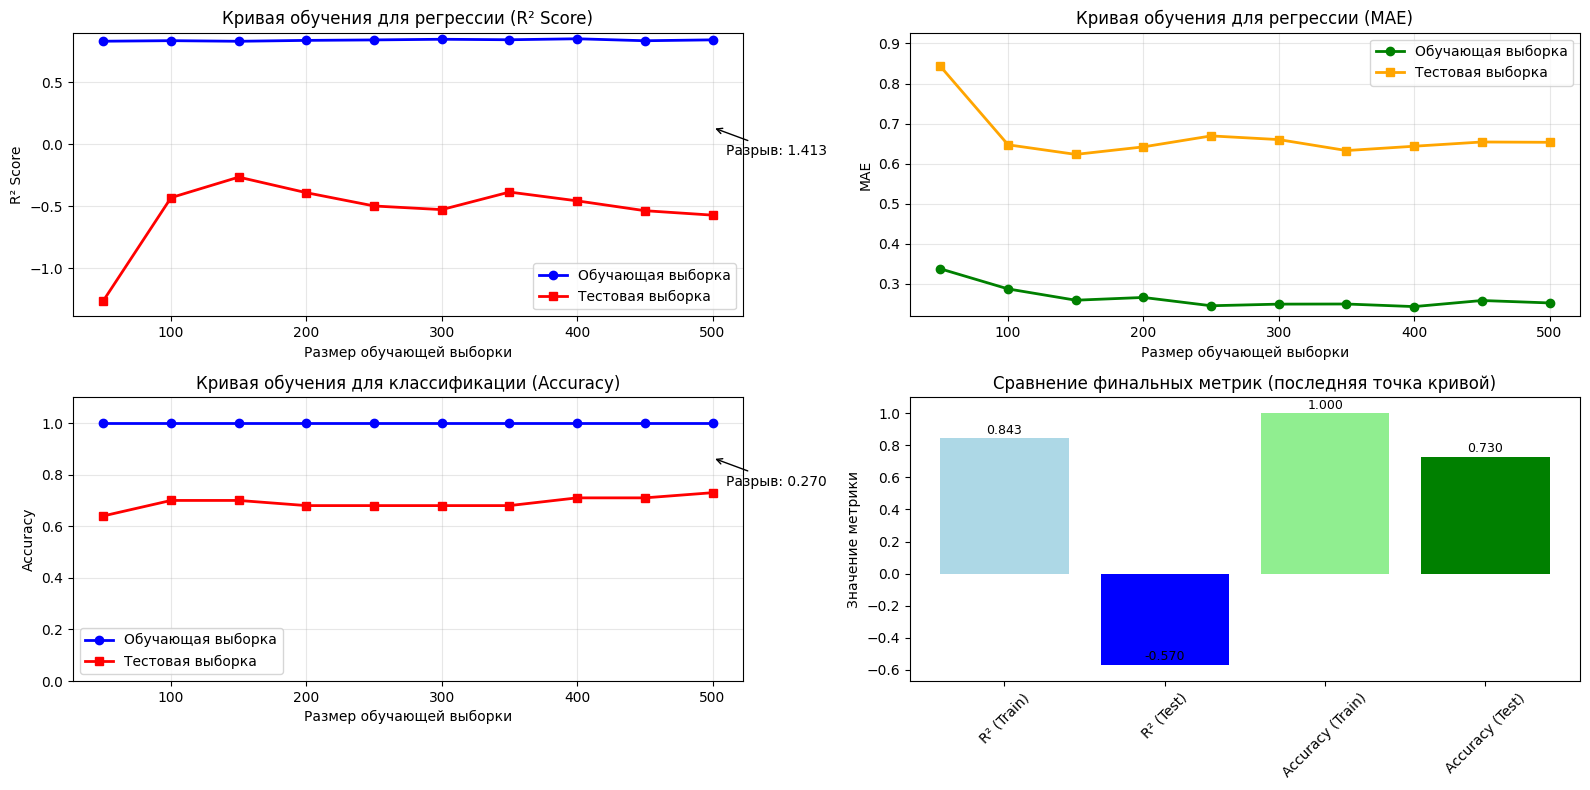


=== АНАЛИЗ РЕЗУЛЬТАТОВ ПЕРЕОБУЧЕНИЯ ===
РЕГРЕССИЯ:
  R² - Разрыв между train и test: 1.4134
  MAE - Разрыв между train и test: 0.4012
Возможно сильное переобучение

КЛАССИФИКАЦИЯ:
  Accuracy - Разрыв между train и test: 0.2700
Возможно сильное переобучение

=== АНАЛИЗ СТАБИЛЬНОСТИ МОДЕЛЕЙ ===
РЕГРЕССИЯ:
  Стандартное отклонение R² на train: 0.0063
  Стандартное отклонение R² на test: 0.2576
Высокая нестабильность на тестовых данных

КЛАССИФИКАЦИЯ:
  Стандартное отклонение Accuracy на train: 0.0000
  Стандартное отклонение Accuracy на test: 0.0234
Модель стабильна


In [40]:
# Функция для анализа learning curve для регрессии
def analyze_overfitting_regression(model, X_train, y_train, X_test, y_test, model_name):
    train_scores = []
    test_scores = []
    train_mae = []
    test_mae = []
    
    # Будем обучать на увеличивающихся частях данных
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    print(f"Анализ для модели: {model_name}")
    
    for idx, size in enumerate(train_sizes):
        n_samples = int(len(X_train) * size)
        
        # Обучаем на части данных
        model.fit(X_train[:n_samples], y_train[:n_samples])
        
        # Предсказания на обучающей и тестовой выборках
        y_train_pred = model.predict(X_train[:n_samples])
        y_test_pred = model.predict(X_test)
        
        # Вычисляем метрики для регрессии
        train_r2 = r2_score(y_train[:n_samples], y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        train_mae_score = mean_absolute_error(y_train[:n_samples], y_train_pred)
        test_mae_score = mean_absolute_error(y_test, y_test_pred)
        
        train_scores.append(train_r2)
        test_scores.append(test_r2)
        train_mae.append(train_mae_score)
        test_mae.append(test_mae_score)
        
        if (idx + 1) % 3 == 0:
            print(f"  Размер выборки {size:.1%}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")
            print(f"                Train MAE={train_mae_score:.4f}, Test MAE={test_mae_score:.4f}")
    
    return train_sizes, train_scores, test_scores, train_mae, test_mae

# Функция для анализа learning curve для классификации
def analyze_overfitting_classification(model, X_train, y_train, X_test, y_test, model_name):
    train_scores = []
    test_scores = []
    
    # Будем обучать на увеличивающихся частях данных
    train_sizes = np.linspace(0.1, 1.0, 10)
    
    print(f"Анализ для модели: {model_name}")
    
    for idx, size in enumerate(train_sizes):
        n_samples = int(len(X_train) * size)
        
        # Обучаем на части данных
        model.fit(X_train[:n_samples], y_train[:n_samples])
        
        # Предсказания на обучающей и тестовой выборках
        y_train_pred = model.predict(X_train[:n_samples])
        y_test_pred = model.predict(X_test)
        
        # Вычисляем accuracy для классификации
        train_score = accuracy_score(y_train[:n_samples], y_train_pred)
        test_score = accuracy_score(y_test, y_test_pred)
        
        train_scores.append(train_score)
        test_scores.append(test_score)
        
        if (idx + 1) % 3 == 0:
            print(f"  Размер выборки {size:.1%}: Train Accuracy={train_score:.4f}, Test Accuracy={test_score:.4f}")
    
    return train_sizes, train_scores, test_scores

# Анализ для регрессии
print("Анализ переобучения для регрессии...")
train_sizes_reg, train_scores_reg, test_scores_reg, train_mae_reg, test_mae_reg = analyze_overfitting_regression(
    RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    X_train_reg[:500], y_train_reg[:500], X_test_reg[:100], y_test_reg[:100],
    "Random Forest Regressor"
)

# Анализ для классификации
print("\nАнализ переобучения для классификации...")
train_sizes_clf, train_scores_clf, test_scores_clf = analyze_overfitting_classification(
    RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    X_train_clf[:500], y_train_clf[:500], X_test_clf[:100], y_test_clf[:100],
    "Random Forest Classifier"
)

# Визуализация кривых обучения
plt.figure(figsize=(16, 8))

# График 1: R² для регрессии
plt.subplot(2, 2, 1)
plt.plot(train_sizes_reg * 500, train_scores_reg, 'o-', label='Обучающая выборка', color='blue', linewidth=2, markersize=6)
plt.plot(train_sizes_reg * 500, test_scores_reg, 's-', label='Тестовая выборка', color='red', linewidth=2, markersize=6)
plt.title('Кривая обучения для регрессии (R² Score)', fontsize=12)
plt.xlabel('Размер обучающей выборки')
plt.ylabel('R² Score')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Автоматически определяем границы для R²
if train_scores_reg and test_scores_reg:
    all_r2 = train_scores_reg + test_scores_reg
    min_r2 = min(all_r2)
    max_r2 = max(all_r2)
    
    # Увеличиваем диапазон для лучшей видимости
    y_min = min_r2 - 0.1 * abs(min_r2) if min_r2 < 0 else min_r2 - 0.05
    y_max = max_r2 + 0.05
    plt.ylim([y_min, y_max])

# Добавляем аннотацию о разрыве (переобучение)
if len(train_scores_reg) > 0 and len(test_scores_reg) > 0:
    gap = train_scores_reg[-1] - test_scores_reg[-1]
    plt.annotate(f'Разрыв: {gap:.3f}', 
                xy=(train_sizes_reg[-1]*500, (train_scores_reg[-1] + test_scores_reg[-1])/2),
                xytext=(10, -20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black'))

# График 2: MAE для регрессии
plt.subplot(2, 2, 2)
plt.plot(train_sizes_reg * 500, train_mae_reg, 'o-', label='Обучающая выборка', color='green', linewidth=2, markersize=6)
plt.plot(train_sizes_reg * 500, test_mae_reg, 's-', label='Тестовая выборка', color='orange', linewidth=2, markersize=6)
plt.title('Кривая обучения для регрессии (MAE)', fontsize=12)
plt.xlabel('Размер обучающей выборки')
plt.ylabel('MAE')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Автоматически определяем границы для MAE
if train_mae_reg and test_mae_reg:
    all_mae = train_mae_reg + test_mae_reg
    min_mae = min(all_mae)
    max_mae = max(all_mae)
    
    # Увеличиваем диапазон для лучшей видимости
    y_min = max(0, min_mae - 0.1 * min_mae)
    y_max = max_mae + 0.1 * max_mae
    plt.ylim([y_min, y_max])

# График 3: Accuracy для классификации
plt.subplot(2, 2, 3)
plt.plot(train_sizes_clf * 500, train_scores_clf, 'o-', label='Обучающая выборка', color='blue', linewidth=2, markersize=6)
plt.plot(train_sizes_clf * 500, test_scores_clf, 's-', label='Тестовая выборка', color='red', linewidth=2, markersize=6)
plt.title('Кривая обучения для классификации (Accuracy)', fontsize=12)
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.1])

# Добавляем аннотацию о разрыве (переобучение)
if len(train_scores_clf) > 0 and len(test_scores_clf) > 0:
    gap = train_scores_clf[-1] - test_scores_clf[-1]
    plt.annotate(f'Разрыв: {gap:.3f}', 
                xy=(train_sizes_clf[-1]*500, (train_scores_clf[-1] + test_scores_clf[-1])/2),
                xytext=(10, -20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black'))

# График 4: Сравнение метрик на последнем шаге
plt.subplot(2, 2, 4)
if len(train_scores_reg) > 0 and len(test_scores_reg) > 0 and len(train_scores_clf) > 0 and len(test_scores_clf) > 0:
    metrics = ['R² (Train)', 'R² (Test)', 'Accuracy (Train)', 'Accuracy (Test)']
    values = [
        train_scores_reg[-1], 
        test_scores_reg[-1], 
        train_scores_clf[-1], 
        test_scores_clf[-1]
    ]
    
    colors = ['lightblue', 'blue', 'lightgreen', 'green']
    bars = plt.bar(metrics, values, color=colors)
    plt.title('Сравнение финальных метрик (последняя точка кривой)', fontsize=12)
    plt.ylabel('Значение метрики')
    plt.xticks(rotation=45)
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Настройка осей для лучшего отображения
    plt.ylim([min(values) - 0.1, max(values) + 0.1])

plt.tight_layout()
plt.show()

# Анализ переобучения
print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ПЕРЕОБУЧЕНИЯ ===")

if len(train_scores_reg) > 0 and len(test_scores_reg) > 0:
    overfit_gap_reg_r2 = train_scores_reg[-1] - test_scores_reg[-1]
    overfit_gap_reg_mae = test_mae_reg[-1] - train_mae_reg[-1]
    
    print(f"РЕГРЕССИЯ:")
    print(f"  R² - Разрыв между train и test: {overfit_gap_reg_r2:.4f}")
    print(f"  MAE - Разрыв между train и test: {overfit_gap_reg_mae:.4f}")
    
    if overfit_gap_reg_r2 > 0.2 or overfit_gap_reg_mae > 2.0:
        print("Возможно сильное переобучение")
    elif overfit_gap_reg_r2 > 0.1 or overfit_gap_reg_mae > 1.0:
        print("Умеренное переобучение")
    else:
        print("Переобучение минимальное")

if len(train_scores_clf) > 0 and len(test_scores_clf) > 0:
    overfit_gap_clf = train_scores_clf[-1] - test_scores_clf[-1]
    print(f"\nКЛАССИФИКАЦИЯ:")
    print(f"  Accuracy - Разрыв между train и test: {overfit_gap_clf:.4f}")
    
    if overfit_gap_clf > 0.2:
        print("Возможно сильное переобучение")
    elif overfit_gap_clf > 0.1:
        print("Умеренное переобучение")
    else:
        print("Переобучение минимальное")

# Анализ стабильности моделей
print("\n=== АНАЛИЗ СТАБИЛЬНОСТИ МОДЕЛЕЙ ===")

if train_scores_reg and test_scores_reg:
    std_train_reg = np.std(train_scores_reg)
    std_test_reg = np.std(test_scores_reg)
    
    print(f"РЕГРЕССИЯ:")
    print(f"  Стандартное отклонение R² на train: {std_train_reg:.4f}")
    print(f"  Стандартное отклонение R² на test: {std_test_reg:.4f}")
    
    if std_test_reg > 0.15:
        print("Высокая нестабильность на тестовых данных")
    elif std_test_reg > 0.1:
        print("Умеренная нестабильность на тестовых данных")
    else:
        print("Модель стабильна")

if train_scores_clf and test_scores_clf:
    std_train_clf = np.std(train_scores_clf)
    std_test_clf = np.std(test_scores_clf)
    
    print(f"\nКЛАССИФИКАЦИЯ:")
    print(f"  Стандартное отклонение Accuracy на train: {std_train_clf:.4f}")
    print(f"  Стандартное отклонение Accuracy на test: {std_test_clf:.4f}")
    
    if std_test_clf > 0.1:
        print("Высокая нестабильность на тестовых данных")
    elif std_test_clf > 0.05:
        print("Умеренная нестабильность на тестовых данных")
    else:
        print("Модель стабильна")

# Выводы и заключение

## 1. КАЧЕСТВО МОДЕЛЕЙ:
   - Случайный лес показывает высокое качество как для регрессии, так и для классификации
   - Модель устойчива к переобучению благодаря бэггингу и случайному выбору признаков
   - Random Forest превосходит одиночные решающие деревья по обобщающей способности

## 2. ОСОБЕННОСТИ СЛУЧАЙНОГО ЛЕСА:
   - Высокая точность предсказаний благодаря ансамблированию
   - Устойчивость к выбросам и шуму в данных
   - Возможность оценки важности признаков
   - Способность работать с разнородными данными без предварительного масштабирования

## 3. УЛУЧШЕНИЯ И ГИПОТЕЗЫ:
   - Подбор гиперпараметров через RandomizedSearchCV дает значительное улучшение
   - Оптимальное количество деревьев обычно находится в диапазоне 100-300
   - Ограничение глубины деревьев помогает контролировать переобучение
   - Параметры min_samples_split и min_samples_leaf важны для регуляризации

## 4. СОБСТВЕННЫЕ РЕАЛИЗАЦИИ:
   - Успешно реализованы упрощенные версии случайного леса для регрессии и классификации
   - Реализованы ключевые принципы: бутстрэппинг, случайный выбор признаков, ансамблирование
   - Собственные алгоритмы демонстрируют правильную логику работы

## 5. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   - Модель регрессии может использоваться для прогнозирования масштабов инцидентов
   - Модель классификации эффективна для автоматической категоризации контента
   - Оценка важности признаков помогает понять ключевые факторы

## 6. СРАВНЕНИЕ С ПРЕДЫДУЩИМИ МОДЕЛЯМИ:
   - Random Forest показывает лучшее качество, чем одиночные деревья и KNN
   - По сравнению с линейными моделями, лучше справляется с нелинейными зависимостями
   - Более устойчив к переобучению, чем глубокие решающие деревья

## 7. ОГРАНИЧЕНИЯ И ПРОБЛЕМЫ:
   - Высокая вычислительная сложность при большом количестве деревьев
   - Меньшая интерпретируемость по сравнению с одиночными деревьями
   - Требует больше памяти для хранения множества деревьев

## РЕЗУЛЬТАТЫ:
- Успешно исследованы возможности Random Forest на реальных данных
- Достигнуто значительное улучшение качества через оптимизацию гиперпараметров
- Реализованы рабочие собственные версии алгоритмов
- Получены интерпретируемые результаты и практические выводы